In [1]:
#加载必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets,transforms

In [2]:
#定义超参数
BATCH_SIZE= 128 #每批处理的数据可以自己定义，也可以是64或16，根据电脑性能决定
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 50 #训练数据集的轮次，可更改

In [3]:
#构建pipeline，对图像做处理
pipeline = transforms.Compose([
    transforms.ToTensor(),#将图片转换成tensor张量
    transforms.Normalize((0.1307),(0.3081))#正则化，当模型训练过拟合时，可以降低模型的复杂度
])

In [4]:
#下载，加载数据
from torch.utils.data import DataLoader
train_set = datasets.MNIST("data", train=True, download=True, transform=pipeline)
test_set = datasets.MNIST("data", train=False, download=True, transform=pipeline)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True)

In [5]:
#插入：如何读取data中的图片，直接打开是不行的，因为文件格式不对：原始二进制格式
with open("./data/MNIST/raw/train-images-idx3-ubyte","rb") as f:        #rb:Read Binary打开文件夹
    file = f.read()    #将整个文件的所有字节 (Bytes) 一次性读入内存，存放在变量 file 中

In [6]:
#显示图片
image1 = [int(str(item).encode("ascii"),10) for item in file[16:16+784]]    #item：代表每一个像素的灰度值（0-255）
print(image1)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 18, 18, 18, 126, 136, 175, 26, 166, 255, 247, 127, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30, 36, 94, 154, 170, 253, 253, 253, 253, 253, 225, 172, 253, 242, 195, 64, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 49, 238, 253, 253, 253, 253, 253, 253, 253, 253, 251, 93, 82, 82, 56, 39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 18, 219, 253, 253, 253, 253, 253, 198, 182, 247, 241, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 80, 156, 107, 253, 253, 205, 11, 0, 43, 154, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14, 1, 154, 253, 90, 0, 

In [7]:
import cv2    #OpenCV 主要承担 数据预处理 (Data Preprocessing) 和 图像增强 (Image Augmentation) 的任务 读写图像，几何变换，颜色处理，绘制标注
import numpy as np

image1_np = np.array(image1, dtype=np.uint8).reshape(28,28,1)   #这里的1是channel通道用于记录一种颜色的强度，由于是灰度图，故只需要一个，如果是彩色图就要用三个（三原色）

print(image1_np.shape)

(28, 28, 1)


In [8]:
cv2.imwrite("digit.jpg", image1_np)#显示图片

True

In [9]:
#构建网络模型
class Digit(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,10,5) #1:灰度图片的通道 ， 10：输出通道  ，5：kernel卷积核
        self.conv2 = nn.Conv2d(10,20,3) #10：输入通道  20：输出通道  3：kernel
        self.fc1 = nn.Linear(20*10*10,500)  #20*10*10:输入通道，  500：输出通道
        self.fc2= nn.Linear(500,10)  #500:输入通道，  10：输出通道

    def forward(self,x):
        input_size = x.size(0) #batch_size
        x = self.conv1(x) #输入：batch*1*28*28，  输出：batch*10*24*24(28-5+1)
        x = F.relu(x)  #激活层,保持shape不变：batch*10*24*24(28-5+1)
        x = F.max_pool2d(x,2,2)  #池化层：对图片进行压缩（降采样）（用于筛选） 输入：batch*10*24*24(28-5+1)  输出：batch*10*12*12  

        x = self.conv2(x) #输入：batch*10*12*12  输出：batch*20*10*10(12-3+1)
        x = F.relu(x)  #激活层,保持shape不变：batch*20*10*10

        x = x.view(input_size,-1) #flattern拉平（变成一条线） -1：自动计算维度：20*10*10=2000

        x = self.fc1(x) #输入：batch*2000  输出：batch*500
        x = F.relu(x)  #激活层,保持shape不变：batch*500

        x = self.fc2(x)  #输入：batch*500  输出：batch*10

        output = F.log_softmax(x,dim=1)  #计算分类后每个数字的概率值  dim=1表示按行计算

        return output

In [10]:
#定义优化器
model = Digit().to(DEVICE) #创建一个模型部署到设备上(实例化)

optimizer = optim.Adam(model.parameters())

In [11]:
#定义训练方法
def train_model(model,train_loader,optimizer,device,epoch):
    #模型训练
    model.train()
    for batch_index,(data,target) in enumerate(train_loader):
        #部署到device上去
        data, target = data.to(device) ,target.to(device)
        #梯度初始化为0
        optimizer.zero_grad()
        #训练结果
        output = model(data)
        #计算loss
        loss = F.cross_entropy(output,target) #交叉熵损失函数
      
        #反向传播
        loss.backward()
        #参数优化
        optimizer.step()
        if batch_index % 5000 == 0:
            print("Train Epoch : {} \t Loss:{:6f}".format(epoch,loss.item()))

In [12]:
#定义测试方法
def test_model(model,device,test_loader):
    #模型验证
    model.eval()
    #正确率
    correct = 0.0
    #测试损失
    test_loss = 0.0
    with torch.no_grad():  #不计算梯度也不会反向传播更新参数，这是训练集里面该做的事
        for data,target in test_loader:
            #部署到device上
            data, target = data.to(device), target.to(device)
            #测试数据
            output = model(data)
            #计算测试损失
            test_loss += F.cross_entropy(output,target).item()
            #找到概率最大值的下标
            pred = output.argmax(dim=1)  #pred = output.max(1, keepdim=True)[1]  
                                         #pred = torch.max(output,dim=1)有多种写法
            #累计正确的值
            correct += pred.eq(target.view_as(pred)).sum().item()
        test_loss /= len(test_loader.dataset)    
        accuracy = 100.0 * correct / len(test_loader.dataset)
        print("Test_Average loss:{:.4f}, Accuracy : {:.3f}\n".format(test_loss,accuracy))
        return accuracy

In [13]:
#调用方法,自动停止训练
TARGET_ACCURACY = 99.0
for epoch in range(1, EPOCHS+1):
    train_model(model,train_loader,optimizer,DEVICE,epoch) #训练模型
    current_accuracy = test_model(model,DEVICE,test_loader) #测试模型，获取当前准确率
    
    if current_accuracy >= TARGET_ACCURACY:
        break


Train Epoch : 1 	 Loss:2.297016
Test_Average loss:0.0004, Accuracy : 98.400

Train Epoch : 2 	 Loss:0.027856
Test_Average loss:0.0003, Accuracy : 98.750

Train Epoch : 3 	 Loss:0.021657
Test_Average loss:0.0003, Accuracy : 98.930

Train Epoch : 4 	 Loss:0.002181
Test_Average loss:0.0003, Accuracy : 98.660

Train Epoch : 5 	 Loss:0.004753
Test_Average loss:0.0004, Accuracy : 98.680

Train Epoch : 6 	 Loss:0.008626
Test_Average loss:0.0002, Accuracy : 99.040



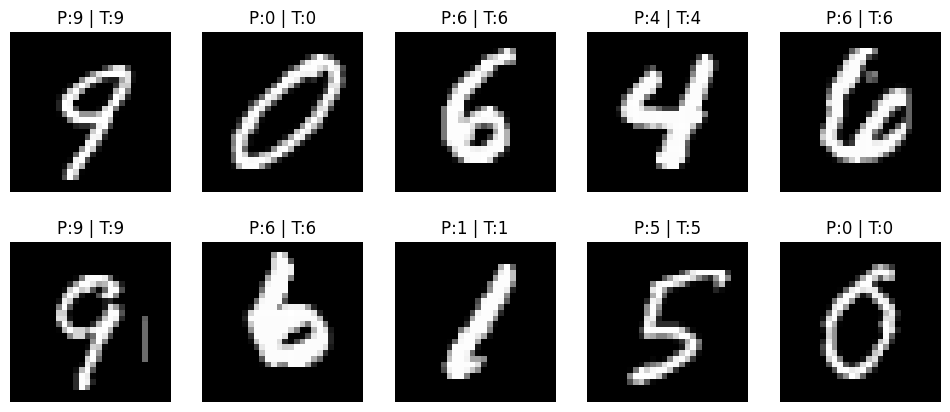

In [21]:
#展示模型预测结果
import matplotlib.pyplot as plt

def visualize_predictions(model,device,test_loader,num_image = 10):
    model.eval()  #切换评估模式
    images, labels = next(iter(test_loader))  #获取一批测试数据    iter():把 test_loader 转化成一个 Iterator（迭代器）  next:拿取数据的动作
    images, labels = images.to (device), labels.to(device)

    #模型预测
    with torch.no_grad(): #进入不记录梯度的模式
        output = model(images)
        pred = output.argmax(dim=1,keepdim=True)  #确定在列方向（0-9）中选出最大值，并保持输出维度是128*1的张量

    #利用matplotlib画图
    plt.figure(figsize=(12,5)) #创建画布，设定尺寸

    for i in range(10):
        plt.subplot(2,5,i+1) #创建两行五列的格子，当前画第i+1个
        
        plt.imshow(images[i].cpu().numpy().squeeze(),cmap = 'gray') 
        #.cpu().numpy(): 把数据从深度学习状态转回普通数字格式。
        #.squeeze(): 把形状从 (1, 28, 28) 挤压成 (28, 28)，因为画图不需要“通道”这个维度。
        
        plt.title(f"P:{pred[i].item()} | T:{labels[i].item()}")  #在图片上方打印预测值和真实标签

        plt.axis('off')
    plt.show()
visualize_predictions(model, DEVICE, test_loader)